In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn pillow tqdm

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --------------- ------------------------ 3.9/9.9 MB 21.7 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 27.6 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 25.3 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------------------------- -- 7.6/8.1 MB 37.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 32.9 MB/s  0:00:00

   -------- ------------------------------- 1/5 [joblib]
   -------- ------------------------------- 1/5 [joblib]
   -------- ------------------------------- 1/5 [joblib]
   -------- ------------------------------- 1/5 [joblib]
   -------- ------------------------------- 1/5 [joblib]
   -------- ------------------------------- 1/5 [joblib]
   -------- ------------------------------- 1/5 [joblib]
   -------- ------------------------------- 1/5 [joblib]
   -------- --------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
BASE_DIR = "01_datasets"

dataset_folders = ["facades", "streets", "textures"]

for folder in dataset_folders:
    path = os.path.join(BASE_DIR, folder)
    files = [
        f for f in os.listdir(path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    print(folder, len(files))

facades 200
streets 200
textures 200


In [4]:
def extract_image_features(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((128, 128))
    
    arr = np.array(img) / 255.0
    
    red_mean = arr[:, :, 0].mean()
    green_mean = arr[:, :, 1].mean()
    blue_mean = arr[:, :, 2].mean()
    
    brightness = arr.mean()
    contrast = arr.std()
    
    red_std = arr[:, :, 0].std()
    green_std = arr[:, :, 1].std()
    blue_std = arr[:, :, 2].std()
    
    return {
        "red_mean": red_mean,
        "green_mean": green_mean,
        "blue_mean": blue_mean,
        "brightness": brightness,
        "contrast": contrast,
        "red_std": red_std,
        "green_std": green_std,
        "blue_std": blue_std
    }

In [5]:
records = []

for dataset_name in dataset_folders:
    folder_path = os.path.join(BASE_DIR, dataset_name)
    
    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    
    for filename in tqdm(image_files, desc=dataset_name):
        image_path = os.path.join(folder_path, filename)
        
        try:
            features = extract_image_features(image_path)
            features["dataset"] = dataset_name
            features["filename"] = filename
            features["image_path"] = image_path
            records.append(features)
        except Exception as e:
            print("Failed:", image_path, e)

df = pd.DataFrame(records)
df.head()

textures: 100%|██████████████████████████████████████████████████████████████████████| 200/200 [00:04<00:00, 48.11it/s]


,red_mean,green_mean,blue_mean,brightness,contrast,red_std,green_std,blue_std,dataset,filename,image_path
0,0.463277,0.460459,0.398281,0.440672,0.212060,0.186845,0.183689,0.252105,facades,000001.jpg,01_datasets\facades\000001.jpg
1,0.494598,0.418554,0.346438,0.419863,0.193738,0.192996,0.187853,0.170554,facades,000002.jpg,01_datasets\facades\000002.jpg
2,0.445092,0.447468,0.437253,0.443271,0.171239,0.171259,0.168335,0.173911,facades,000003.jpg,01_datasets\facades\000003.jpg
3,0.722136,0.704368,0.699272,0.708592,0.324892,0.311730,0.322582,0.339326,facades,facades_001.jpg,01_datasets\facades\facades_001.jpg
4,0.782317,0.803853,0.842616,0.809595,0.283267,0.314405,0.281282,0.246746,facades,facades_002.jpg,01_datasets\facades\facades_002.jpg


In [6]:
os.makedirs("03_outputs/csv", exist_ok=True)

csv_path = "03_outputs/csv/image_features.csv"
df.to_csv(csv_path, index=False)

print("Saved:", csv_path)
print(df.shape)

Saved: 03_outputs/csv/image_features.csv
(600, 11)


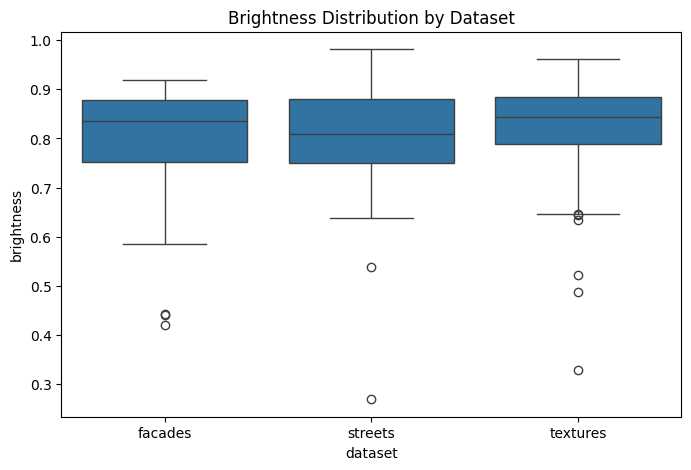

In [7]:
os.makedirs("03_outputs/charts", exist_ok=True)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="dataset", y="brightness")
plt.title("Brightness Distribution by Dataset")
plt.savefig("03_outputs/charts/brightness_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

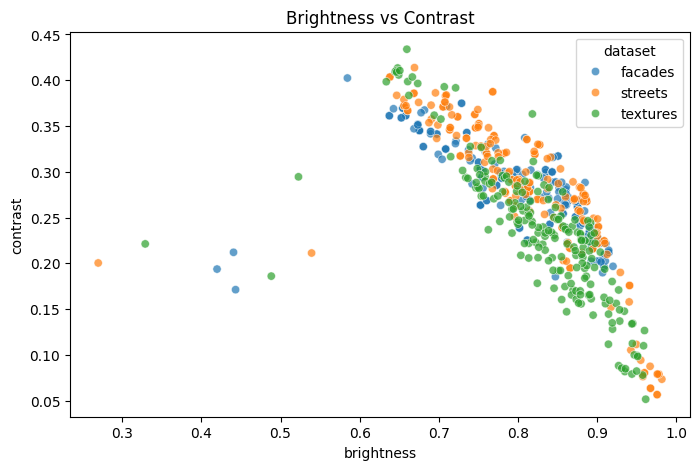

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="brightness",
    y="contrast",
    hue="dataset",
    alpha=0.7
)
plt.title("Brightness vs Contrast")
plt.savefig("03_outputs/charts/brightness_contrast_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
feature_columns = [
    "red_mean", "green_mean", "blue_mean",
    "brightness", "contrast",
    "red_std", "green_std", "blue_std"
]

X = df[feature_columns].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,red_mean,green_mean,blue_mean,brightness,contrast,red_std,green_std,blue_std,dataset,filename,image_path,cluster
0,0.463277,0.460459,0.398281,0.440672,0.212060,0.186845,0.183689,0.252105,facades,000001.jpg,01_datasets\facades\000001.jpg,2
1,0.494598,0.418554,0.346438,0.419863,0.193738,0.192996,0.187853,0.170554,facades,000002.jpg,01_datasets\facades\000002.jpg,2
2,0.445092,0.447468,0.437253,0.443271,0.171239,0.171259,0.168335,0.173911,facades,000003.jpg,01_datasets\facades\000003.jpg,2
3,0.722136,0.704368,0.699272,0.708592,0.324892,0.311730,0.322582,0.339326,facades,facades_001.jpg,01_datasets\facades\facades_001.jpg,1
4,0.782317,0.803853,0.842616,0.809595,0.283267,0.314405,0.281282,0.246746,facades,facades_002.jpg,01_datasets\facades\facades_002.jpg,4


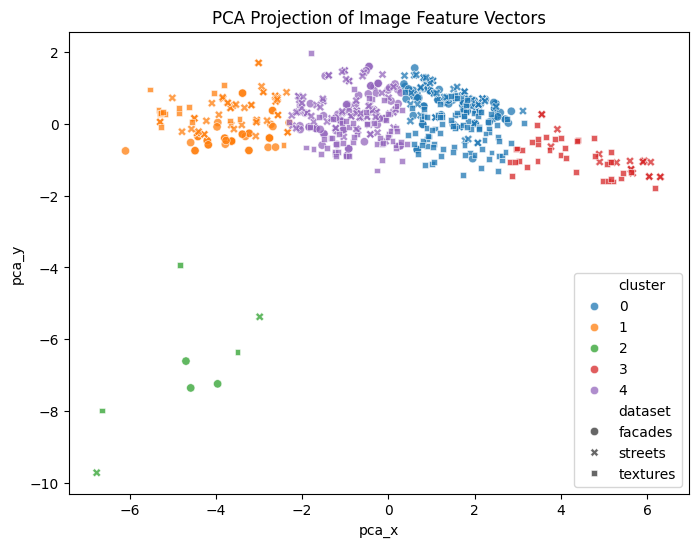

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["pca_x"] = X_pca[:, 0]
df["pca_y"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="pca_x",
    y="pca_y",
    hue="cluster",
    style="dataset",
    palette="tab10",
    alpha=0.75
)
plt.title("PCA Projection of Image Feature Vectors")
plt.savefig("03_outputs/charts/pca_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
final_csv_path = "03_outputs/csv/image_features_with_clusters.csv"
df.to_csv(final_csv_path, index=False)

print("Saved:", final_csv_path)
print(df["cluster"].value_counts())

Saved: 03_outputs/csv/image_features_with_clusters.csv
cluster
0    227
4    199
1    109
3     57
2      8
Name: count, dtype: int64


In [12]:
def extract_histogram_features(image_path, bins=8):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((128, 128))
    
    arr = np.array(img) / 255.0
    
    features = []
    
    for channel in range(3):
        hist, _ = np.histogram(
            arr[:, :, channel],
            bins=bins,
            range=(0, 1),
            density=True
        )
        features.extend(hist)
    
    return np.array(features)

In [13]:
hist_vectors = []
valid_indices = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        vec = extract_histogram_features(row["image_path"], bins=8)
        hist_vectors.append(vec)
        valid_indices.append(idx)
    except Exception as e:
        print("Failed:", row["image_path"], e)

X_hist = np.array(hist_vectors)

print("Histogram vector shape:", X_hist.shape)

100%|████████████████████████████████████████████████████████████████████████████████| 600/600 [00:06<00:00, 99.84it/s]

Histogram vector shape: (600, 24)


In [14]:
scaler_hist = StandardScaler()
X_hist_scaled = scaler_hist.fit_transform(X_hist)

kmeans_hist = KMeans(n_clusters=5, random_state=42, n_init=10)
hist_clusters = kmeans_hist.fit_predict(X_hist_scaled)

df.loc[valid_indices, "hist_cluster"] = hist_clusters
df["hist_cluster"] = df["hist_cluster"].astype(int)

df.head()

,red_mean,green_mean,blue_mean,brightness,contrast,red_std,green_std,blue_std,dataset,filename,image_path,cluster,pca_x,pca_y,hist_cluster
0,0.463277,0.460459,0.398281,0.440672,0.212060,0.186845,0.183689,0.252105,facades,000001.jpg,01_datasets\facades\000001.jpg,2,-4.695664,-6.606456,3
1,0.494598,0.418554,0.346438,0.419863,0.193738,0.192996,0.187853,0.170554,facades,000002.jpg,01_datasets\facades\000002.jpg,2,-4.585104,-7.353482,3
2,0.445092,0.447468,0.437253,0.443271,0.171239,0.171259,0.168335,0.173911,facades,000003.jpg,01_datasets\facades\000003.jpg,2,-3.961164,-7.239895,3
3,0.722136,0.704368,0.699272,0.708592,0.324892,0.311730,0.322582,0.339326,facades,facades_001.jpg,01_datasets\facades\facades_001.jpg,1,-2.758765,-0.393697,3
4,0.782317,0.803853,0.842616,0.809595,0.283267,0.314405,0.281282,0.246746,facades,facades_002.jpg,01_datasets\facades\facades_002.jpg,4,-0.403883,0.337920,1


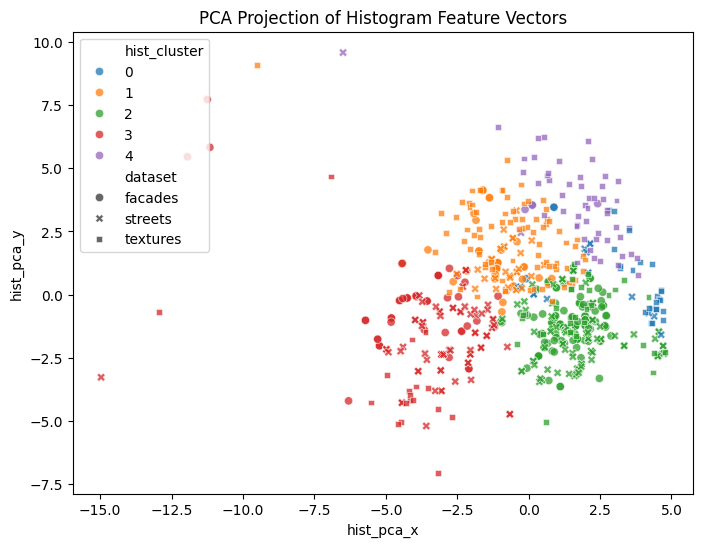

In [15]:
pca_hist = PCA(n_components=2)
X_hist_pca = pca_hist.fit_transform(X_hist_scaled)

df.loc[valid_indices, "hist_pca_x"] = X_hist_pca[:, 0]
df.loc[valid_indices, "hist_pca_y"] = X_hist_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="hist_pca_x",
    y="hist_pca_y",
    hue="hist_cluster",
    style="dataset",
    palette="tab10",
    alpha=0.75
)
plt.title("PCA Projection of Histogram Feature Vectors")
plt.savefig("03_outputs/charts/pca_histogram_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
comparison_csv_path = "03_outputs/csv/image_features_comparison.csv"
df.to_csv(comparison_csv_path, index=False)

print("Saved:", comparison_csv_path)

print("Original feature clusters:")
print(df["cluster"].value_counts())

print("\nHistogram feature clusters:")
print(df["hist_cluster"].value_counts())

Saved: 03_outputs/csv/image_features_comparison.csv
Original feature clusters:
cluster
0    227
4    199
1    109
3     57
2      8
Name: count, dtype: int64

Histogram feature clusters:
hist_cluster
2    217
1    150
3    133
4     56
0     44
Name: count, dtype: int64
